In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("car data.csv")
df.head()

Saving car data.csv to car data (1).csv


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [34]:
df.shape

(301, 9)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [36]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [37]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [38]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [39]:
df["Selling_type"].unique()

array(['Dealer', 'Individual'], dtype=object)

In [40]:
df["Transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [41]:
df["Fuel_Type"].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [42]:
df["Selling_type"].value_counts()

,count
Selling_type,
Dealer,195
Individual,106


In [43]:
df["Transmission"].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [44]:
df["Car_Name"].nunique()

98

In [45]:
df["Car_Name"].value_counts().head(10)

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
ciaz,9
i20,9
innova,9
grand i10,8


In [46]:
df = df.drop("Car_Name", axis=1)

In [47]:
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.236141,-0.047192,-0.524342,-0.182104
Selling_Price,0.236141,1.000000,0.878914,0.029187,-0.088344
Present_Price,-0.047192,0.878914,1.000000,0.203618,0.008058
Driven_kms,-0.524342,0.029187,0.203618,1.000000,0.089216
Owner,-0.182104,-0.088344,0.008058,0.089216,1.000000


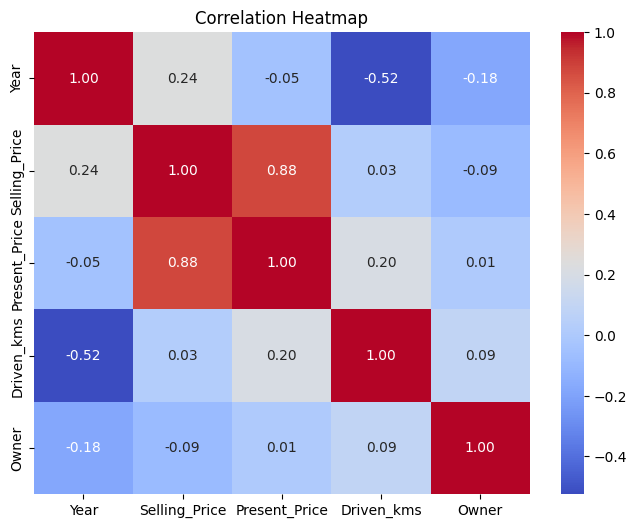

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [49]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [50]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True,
    dtype=int
)

In [51]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1


In [52]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

In [53]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [54]:
X.head()

,Year,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,5.59,27000,0,0,1,0,1
1,2013,9.54,43000,0,1,0,0,1
2,2017,9.85,6900,0,0,1,0,1
3,2011,4.15,5200,0,0,1,0,1
4,2014,6.87,42450,0,1,0,0,1


In [55]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
len(X_train)

240

In [58]:
len(X_test)

61

In [59]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [60]:
model.fit(X_train, y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test)

In [62]:
y_pred[:10]

array([ 2.95433731,  8.17716341,  6.45612271, -1.42337164,  9.08864657,
        7.41793553,  1.33513921,  0.84032259,  1.36320242,  7.49067757])

In [63]:
y_test.head(10)

,Selling_Price
177,0.35
289,10.11
228,4.95
198,0.15
60,6.95
9,7.45
118,1.10
154,0.50
164,0.45
33,6.00


In [64]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8488707839191938
MAE: 1.2163740193336217
MSE: 3.4813498305146187
RMSE: 1.865837568094988


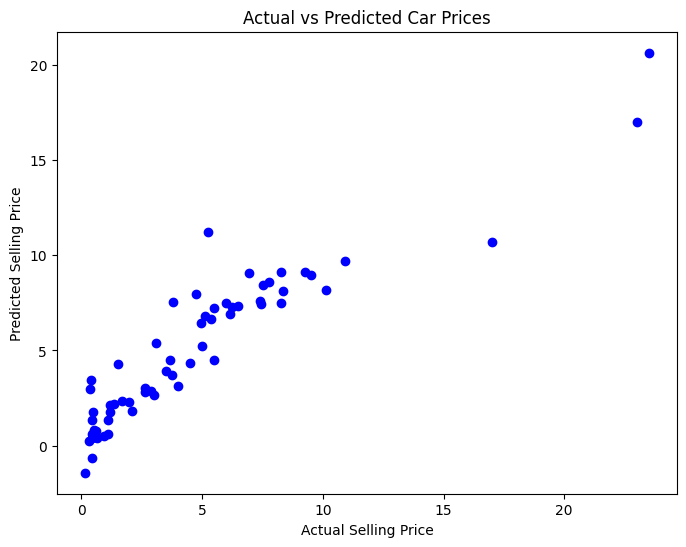

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue')

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

# **Insights:**

1. The dataset contained **301 vehicle records** with no missing values, making it suitable for machine learning without requiring missing value treatment.

2. The dataset included both **numerical** and **categorical** features. Categorical variables such as Fuel Type, Selling Type, and Transmission were successfully converted into numerical values using One-Hot Encoding.

3. **Present Price** showed the strongest positive correlation (**0.88**) with Selling Price, indicating that vehicles with higher current market prices generally have higher selling prices.

4. The **Year** of the vehicle had a positive relationship with Selling Price, suggesting that newer vehicles tend to have higher resale values.

5. The **Driven Kilometers** feature showed a relatively weak linear correlation with Selling Price in this dataset, although it may still contribute when combined with other features.

6. Linear Regression successfully learned the relationship between vehicle features and selling price.

7. The model achieved an **R² Score of 0.85**, meaning it explained approximately **85% of the variation** in vehicle selling prices.

8. The model achieved:

   * **MAE:** 1.22
   * **RMSE:** 1.87

   These values indicate that the model's average prediction error is relatively low, demonstrating good predictive performance.

9. The Actual vs Predicted Price visualization showed that most predicted values were close to the actual selling prices, indicating that the regression model fits the data reasonably well.

10. This project demonstrates how machine learning can assist in estimating vehicle resale prices based on historical vehicle information and specifications.


# **Conclusion**

This project successfully developed a machine learning model to predict vehicle selling prices using Linear Regression.

The project followed a complete machine learning workflow, including data loading, data exploration, data cleaning, categorical feature encoding, feature selection, train-test splitting, model training, prediction, evaluation, and visualization.

After preprocessing the dataset and converting categorical variables into numerical form, a Linear Regression model was trained using Scikit-learn. The model achieved an **R² Score of 0.85**, indicating that it can explain approximately **85% of the variation** in selling prices. The low MAE and RMSE values further demonstrate that the model produces reasonably accurate price predictions.

Correlation analysis showed that **Present Price** is the most influential feature affecting the selling price, while other features such as manufacturing year, ownership history, fuel type, transmission, and driven kilometers also contribute to the prediction.

Overall, this project demonstrates the practical application of machine learning in predicting used vehicle prices. Such predictive models can assist buyers, sellers, dealerships, and online automobile marketplaces in making more informed pricing decisions based on vehicle characteristics.
